In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from skimage.transform import radon, iradon

# Data
Using XCAT dataset 'sampling_300ms_compressed.mat'.
This data originally has dimensions 400x400x50x100. I.e. 100 samples of 50 slices, each 400x400.
Opening the dataset using h5py reverses the order, so it is now 100x50x400x400.

In [9]:
file = h5py.File('data/sampling_300ms_compressed.mat', 'r');
data = file['data2'];

N = 400; # NxN images
SLICES = 50; # slices per sample
SAMPLES = 100; 

print(f"Number of samples: {len(data)}");
print(f"Number of slices: {len(data[0,:,:,:])}");
print(f"Dimensions: {len(data[0,0,:,:])}x{len(data[0,0,0,:])}");

# TODO may extract one breath cycle here

Number of samples: 100
Number of slices: 50
Dimensions: 400x400


In [7]:
# Remember to close the file when done
file.close();

In [ ]:
# Example, extracting one slice at sample 0, slice 10
ex_image = data[0, 10, :, :];
ex_image = np.rot90(ex_image, k=-1, axes=(0,1)); # rotate 90 deg clockwise
plot = plt.figure();
plot = plt.imshow(ex_image, cmap='grey');
plt.title("Example: Sample 0, Slice 10");
plt.savefig('fig/example_slice.png');
plt.show(plot)

In [ ]:
# Animation to demonstrate breathing cycle in XCAT
import matplotlib.animation as animation
from IPython.display import Image, display

images = data[0:99, 10, :, :];
images = np.rot90(images, k=-1, axes=(1,2));

im = plt.imshow(images[0], cmap='grey');

def updateFig(f):
    im.set_array(images[f]);
    return [im];

fig = plt.gcf();
# TODO frames should be 300ms sampled, but there is something strange with the interval param
ani = animation.FuncAnimation(fig, updateFig, frames=range(99), interval=300, blit=False);
ani.save('fig/animation.gif', writer='pillow', fps=20);

plt.close(fig);
display(Image(filename='fig/animation.gif'));

# Radial MRI
(explain radial MRI, golden angle, spokes, etc. here)

Parameters:
- sample_rate: sample rate of dataset (300ms)
- frames: the number of samples in one breath cycle
- tr: repetition time, the time to acquire one spoke [s]
- breaths: the number of breaths in the simulation
- cycle_time: the time [s] of one breath
- spokes: the number of spokes collected

Given the number of frames, breaths, cycle time, and tr, calculate the corresponding number of spokes that will be taken during this time.

In [21]:
# Constants
GOLDEN_ANGLE = 111.246;
sample_rate = 0.3; # 300 ms
frames = 10; # frames to simulate
slice_idx = 10; 

# TODO look at graphs in MATLAB to determine one breathing cycle start/end
# this is currently taking all 100 frames of around 2.5 breaths as one. 
# change to extract frames from one breath and update frames (changing fs as well to be more realistic)

tr = 0.04; # time to acquire 1 spoke [s] - change back to 0.004 s!
breaths = 1;
cycle_time = frames * sample_rate;
spokes = int(np.floor((breaths * cycle_time) / tr));

print(f"Running simulation with {frames} frames at fs={sample_rate}, TR={tr}, {breaths} breaths at {cycle_time}s each: {spokes} spokes.");

angles = np.arange(spokes) * GOLDEN_ANGLE;
angles = np.mod(angles, 180.0);
assert(len(angles) == spokes);

Running simulation with 10 frames at fs=0.3, TR=0.04, 1 breaths at 3.0s each: 75 spokes.


# Forward Process
Project all spokes using radial sampling
Index: the frame of the phantom to project

In [31]:
# Forward process

sinogram = np.zeros((566, spokes));
print(sinogram)

for i in range(spokes):
    t = i * tr; # absolute time of this projection
    idx = int(np.floor(t/sample_rate));
    print(f"idx={idx}");
    p = data[idx, slice_idx, :, :]; # NxN phantom at slice, idx
    sino = radon(p, theta=[angles[i]], circle=False);
    sinogram[:, i] = sino[:, 0];

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
idx=0
idx=0
idx=0
idx=0
idx=0
idx=0
idx=0
idx=0
idx=1
idx=1
idx=1
idx=1
idx=1
idx=1
idx=1
idx=2
idx=2
idx=2
idx=2
idx=2
idx=2
idx=2
idx=2
idx=3
idx=3
idx=3
idx=3
idx=3
idx=3
idx=3
idx=4
idx=4
idx=4
idx=4
idx=4
idx=4
idx=4
idx=4
idx=5
idx=5
idx=5
idx=5
idx=5
idx=5
idx=5
idx=6
idx=6
idx=6
idx=6
idx=6
idx=6
idx=6
idx=6
idx=7
idx=7
idx=7
idx=7
idx=7
idx=7
idx=7
idx=8
idx=8
idx=8
idx=8
idx=8
idx=8
idx=8
idx=8
idx=9
idx=9
idx=9
idx=9
idx=9
idx=9
idx=9


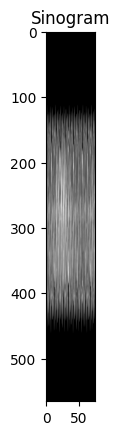

In [32]:
plot = plt.figure();
plot = plt.imshow(sinogram, cmap='grey');
plt.title("Sinogram");
plt.savefig('fig/sinogram.png');
plt.show(plot)

# Example: Static Image, 100 spokes

In [12]:
# Example
GOLDEN_ANGLE = 111.246;
ex_gt = data[0, 10, :, :];
ex_gt = np.rot90(ex_gt, k=-1, axes=(0,1));
ex_gt = ex_gt.astype(float)

angles = np.arange(100) * GOLDEN_ANGLE;
angles = np.mod(angles, 180.0);

# forward process
ex_sinogram = radon(ex_gt, theta=angles, circle=False);

# backward process
ex_reconstructed = iradon(ex_sinogram, theta=angles, filter_name='ramp', circle=False);

# clip negative values
ex_reconstructed = np.clip(ex_reconstructed, 0, None);

# normalize
ex_gt_norm = ex_gt / np.max(ex_gt);
ex_reconstructed_norm = ex_reconstructed / np.max(ex_reconstructed);

# calculate difference
diff = np.abs(ex_gt_norm - ex_reconstructed_norm);

print(f"Ground Truth Min: {np.min(ex_gt)}, Max: {np.max(ex_gt)}")
print(f"Recon Min: {np.min(ex_reconstructed)}, Max: {np.max(ex_reconstructed)}")
print(f"Diff Min: {np.min(diff)}, Max: {np.max(diff)}")

Ground Truth Min: 0.0, Max: 139.0
Recon Min: 0.0, Max: 146.2522567430092
Diff Min: 0.0, Max: 0.32915931191576214


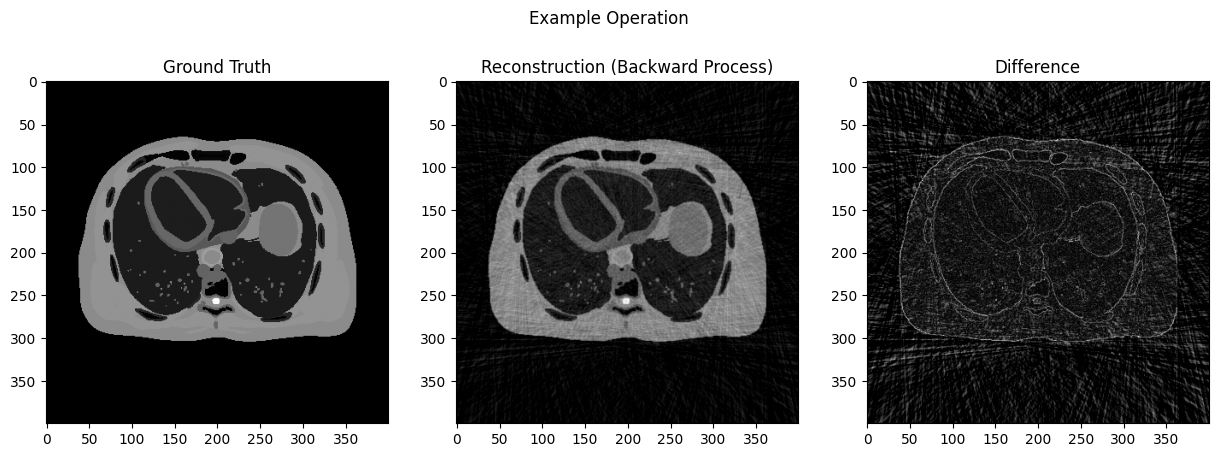

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5));
fig.suptitle('Example Operation');

ax1.set_title('Ground Truth');
im1 = ax1.imshow(ex_gt, cmap='grey');

ax2.set_title('Reconstruction (Backward Process)');
im2 = ax2.imshow(ex_reconstructed, cmap='grey');

ax3.set_title('Difference');
im3 = ax3.imshow(diff, cmap='grey');

#vmax = np.percentile(diff, 98)
#im3 = ax3.imshow(diff, cmap='grey', vmin=0, vmax=vmax)
#plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

#vmax = np.percentile(np.abs(diff), 99)
#im3 = ax3.imshow(diff, cmap='seismic', vmin=-vmax, vmax=vmax);
#plt.colorbar(im3, ax=ax3, fraction=0.46, pad=0.04);

plt.savefig('fig/Example.png');
plt.show();